In [52]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from category_encoders import TargetEncoder, OrdinalEncoder


In [48]:
df = pd.read_csv(r"C:\Users\Odogw\OneDrive\Desktop\Machine Learning\computer_prices_all.csv")


In [53]:
# Load Dataset
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nFirst 5 rows:")
print(df.head())

Dataset shape: (100000, 33)

Columns:
['device_type', 'brand', 'model', 'release_year', 'os', 'form_factor', 'cpu_brand', 'cpu_model', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_brand', 'gpu_model', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_type', 'storage_gb', 'storage_drive_count', 'display_type', 'display_size_in', 'resolution', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'wifi', 'bluetooth', 'weight_kg', 'warranty_months', 'price']

First 5 rows:
  device_type     brand              model  release_year       os form_factor  \
0     Desktop   Samsung  Samsung Forge XDI          2022  Windows         ATX   
1      Laptop   Samsung    Samsung Pro KM8          2022  Windows  Mainstream   
2     Desktop    Lenovo   Lenovo Strix BIE          2024    macOS         SFF   
3     Desktop      Dell      Dell Cube AXR          2024  Windows         ATX   
4      Laptop  Gigabyte   Gigabyte Pro IX1          2024    Linux      Gaming   

  cpu_bra

In [ ]:
# Category Consolidation

# Keep brand and gpu_model as-is or consolidate lightly
# Skip model because it is almost unique for every row
consolidate_cols = ['brand', 'cpu_model', 'gpu_model']

for col in consolidate_cols:
    counts = df[col].value_counts()
    keep = counts[counts > len(df) * 0.01].index   # keep categories above 1%
    df[col] = np.where(df[col].isin(keep), df[col], 'Other')

In [ ]:
# Define Features and Target
X = df.drop(columns=['price'])
y = df['price']

In [57]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

In [59]:
# Tiered Encoding Strategy
# A. Ordinal Encoding (For CPU/GPU Tiers)
# A. Ordinal Encoding for tier columns
ord_cols = ['cpu_tier', 'gpu_tier']
ord_enc = OrdinalEncoder(cols=ord_cols)
X_train = ord_enc.fit_transform(X_train)
X_test = ord_enc.transform(X_test)

In [60]:
# B. One-hot encode lower-cardinality categorical columns
low_card_cols = [
    'device_type', 'os', 'form_factor', 'cpu_brand', 'gpu_brand',
    'storage_type', 'display_type', 'resolution', 'wifi'
]

In [61]:
# keep only columns that actually exist
low_card_cols = [col for col in low_card_cols if col in X_train.columns]

X_train = pd.get_dummies(X_train, columns=low_card_cols, drop_first=False)
X_test = pd.get_dummies(X_test, columns=low_card_cols, drop_first=False)

# Align train/test columns after one-hot encoding
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# C. Target encoding for high-cardinality columns
high_card_cols = ['brand', 'model', 'cpu_model', 'gpu_model']
high_card_cols = [col for col in high_card_cols if col in X_train.columns]

target_enc = TargetEncoder(cols=high_card_cols, smoothing=1.0)
X_train_final = target_enc.fit_transform(X_train, y_train)
X_test_final = target_enc.transform(X_test)

print("\nFinal Predictor Count:", X_train_final.shape[1])


Final Predictor Count: 66


In [62]:
# Fit Regression Model
model = LinearRegression()
model.fit(X_train_final, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [63]:
# Predictions
y_train_pred = model.predict(X_train_final)
y_test_pred = model.predict(X_test_final)

In [64]:
# Model Performance
r2 = r2_score(y_test, y_test_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\nModel Performance:")
print("R^2  =", round(r2, 4))
print("RMSE =", round(rmse, 4))


Model Performance:
R^2  = 0.8584
RMSE = 216.2339


In [65]:
# Residual Analysis
residuals = y_test - y_test_pred

# Standardized residuals (z-scores)
residual_mean = residuals.mean()
residual_std = residuals.std()

std_residuals = (residuals - residual_mean) / residual_std

In [66]:
# Detect Anomalies
threshold = 2.5
anomalies_idx = np.where(np.abs(std_residuals) > threshold)[0]

print("\nNumber of anomalies detected:", len(anomalies_idx))


Number of anomalies detected: 232


In [68]:
# Build Anomaly Results Table
results = X_test.copy()
results['actual_price'] = y_test.values
results['predicted_price'] = y_test_pred
results['residual'] = residuals.values
results['std_residual'] = std_residuals.values
results['abs_std_residual'] = np.abs(std_residuals.values)

anomalies = results.iloc[anomalies_idx].copy()
anomalies = anomalies.sort_values(by='abs_std_residual', ascending=False)

print("\nTop 10 anomalies:")
print(anomalies[['actual_price', 'predicted_price', 'residual', 'std_residual']].head(10))



Top 10 anomalies:
       actual_price  predicted_price     residual  std_residual
97808       8579.99      2462.594755  6117.395245     28.300464
44266       6514.99      1725.637060  4789.352940     22.158658
15397       5160.99      1674.119737  3486.870263     16.135057
87439       5031.99      1706.536170  3325.453830     15.388553
78468       5421.99      2117.406468  3304.583532     15.292034
63283       4732.99      1703.802864  3029.187136     14.018406
51743       4855.99      2035.763588  2820.226412     13.052024
28814       3981.99      1393.731439  2588.258561     11.979241
13274       4461.99      2000.060496  2461.929504     11.395006
29049       4141.99      1737.286761  2404.703239     11.130351


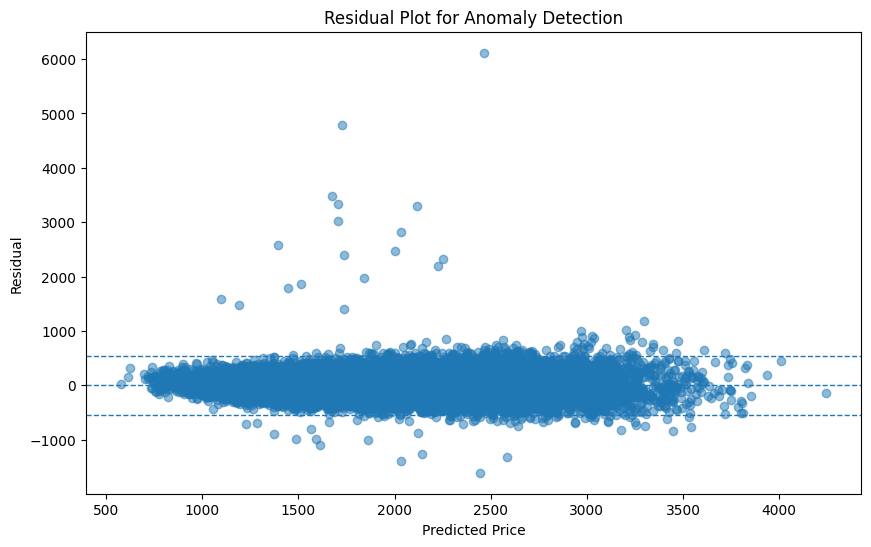

In [69]:
# Plot 1: Predicted Price vs Residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.axhline(0, linestyle='--', linewidth=1)
plt.axhline(threshold * residual_std, linestyle='--', linewidth=1)
plt.axhline(-threshold * residual_std, linestyle='--', linewidth=1)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot for Anomaly Detection")
plt.show()

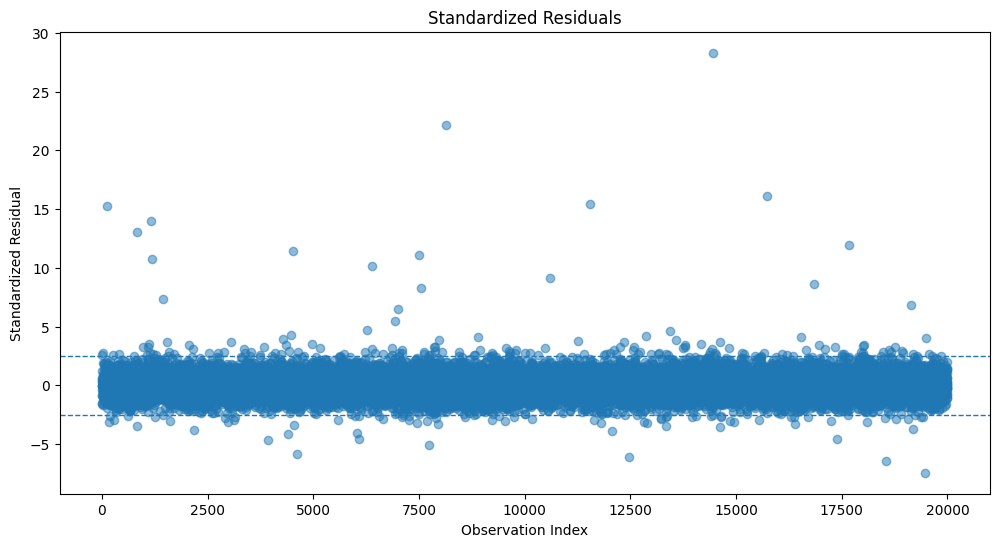

In [70]:
# Plot 2: Standardized Residuals by Observation
plt.figure(figsize=(12, 6))
plt.scatter(range(len(std_residuals)), std_residuals, alpha=0.5)
plt.axhline(threshold, linestyle='--', linewidth=1)
plt.axhline(-threshold, linestyle='--', linewidth=1)
plt.xlabel("Observation Index")
plt.ylabel("Standardized Residual")
plt.title("Standardized Residuals")
plt.show()

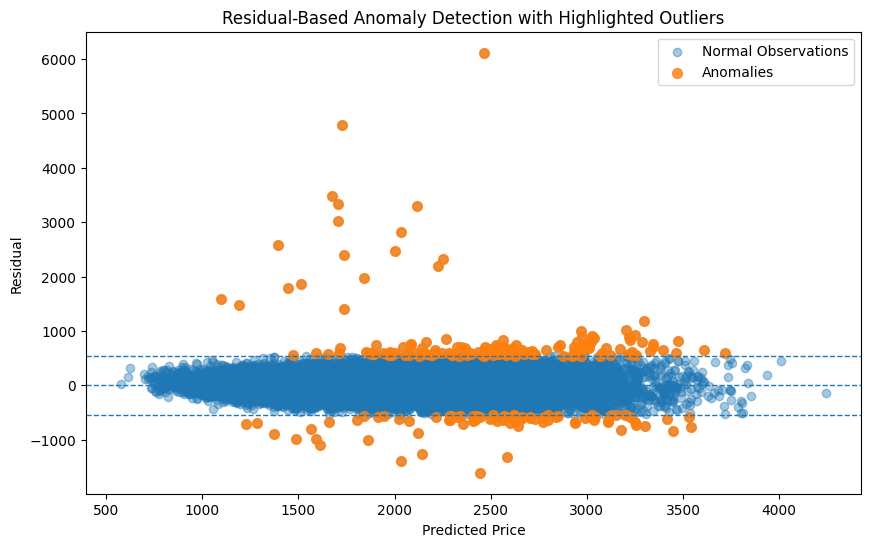

In [71]:
# Plot 3: Highlight Anomalies
plt.figure(figsize=(10, 6))
plt.scatter(y_test_pred, residuals, alpha=0.4, label='Normal Observations')
plt.scatter(
    y_test_pred[anomalies_idx],
    residuals.iloc[anomalies_idx],
    s=50,
    alpha=0.8,
    label='Anomalies'
)
plt.axhline(0, linestyle='--', linewidth=1)
plt.axhline(threshold * residual_std, linestyle='--', linewidth=1)
plt.axhline(-threshold * residual_std, linestyle='--', linewidth=1)
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual-Based Anomaly Detection with Highlighted Outliers")
plt.legend()
plt.show()

In [72]:
# Summary
print("\nSummary:")
print(f"The regression model predicted computer prices with R^2 = {r2:.4f} and RMSE = {rmse:.2f}.")
print(f"Using a standardized residual threshold of ±{threshold}, {len(anomalies_idx)} anomalies were identified.")
print("These anomalies represent computers whose prices are much higher or lower than expected based on their specifications.")


Summary:
The regression model predicted computer prices with R^2 = 0.8584 and RMSE = 216.23.
Using a standardized residual threshold of ±2.5, 232 anomalies were identified.
These anomalies represent computers whose prices are much higher or lower than expected based on their specifications.
